# Prepare

Run `generate_grid_graph_json.py` on whatever configuration you please

# Sampling
Run Julia code to sample partitions, e.g.
```
./sampling/run.sh --map-file data/graph/grid_graph_5_by_5.json --output-file local/output/grid5x5/atlas.jsonl.gz --cycle-walk-steps 1e5 --pop-dev 0.1
```
On a Windows machine through Powershell, something like the following might work:
```
julia --project="sampling/runCycleWalkEnv" sampling/run_cyclewalk.jl --map-file data/graph/grid_graph_5_by_5.json --output-file local/output/grid5x5/atlas.jsonl.gz --cycle-walk-steps 1e5 --pop-dev 0.1 --rng-seed 42
```

# Analysis

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from data import generate_grid_shape, generate_shape_from_json
from hierachical import HClusters
from sample import SampleProcessor
from utils import (
    plot_district,
    plot_plan,
    plot_words_centroids,
    plot_words_list,
    plot_district_by_uid,
)
from word import PlanWordBuilder, WordStat
from scipy.cluster.hierarchy import dendrogram, linkage
from voronoi_gdf import gdf_from_graph_json
import time

square_side = 50
num_districts = 6

PRECINCT_FN = "data/graph/regular_hex_graph_50x50x50_6.json"
SAMPLE_FN = "local/output/reghex50x50x50-6/atlas.jsonl.gz"
OUT_DIR = "local/output/reghex50x50x50-6/processed"
# gdf = generate_grid_shape(square_side)
# gdf = generate_shape_from_json(PRECINCT_FN)

start_time = time.time()
gdf = gdf_from_graph_json(PRECINCT_FN, buffer_factor=0.01)
end_time = time.time()

print(f'gdf generation time: {end_time - start_time} seconds')

is_huge = True if square_side > 4 else False

C:\Users\edzh0\anaconda3\envs\gmstrat\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


gdf generation time: 386.8940725326538 seconds


In [2]:
print(gdf.iloc[0])

node_name                                                    (-49,0)
precinct_id_str                                              (-49,0)
id                                                                 0
border_length                                                      3
x_location                                                     -49.0
y_location                                                       0.0
area                                                               1
population                                                         1
geometry           POLYGON ((-48.5 0.2886751345948129, -48.5 -0.2...
Name: 0, dtype: object


In [3]:
sp = SampleProcessor(PRECINCT_FN, OUT_DIR)
# run this once to process samples and dump artifacts for future use
sp.clean()
sp.process_samples([SAMPLE_FN], max_length=1000, min_step=100)
sp.load_processed()

Reading local\output\reghex50x50x50-6\atlas.jsonl.gz


plans: 100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1879.23it/s]


We give each district a unique `district_uid'. Districts are stored via the precincts that they contain (i.e. as an array of ints).

In [4]:
sp.df_districts.head()

,district_str,district_uid
0,0.1.2.3.4.5.50.51.52.53.54.101.102.103.104.105...,0
1,0.1.2.3.4.5.50.51.52.53.54.55.101.102.103.104....,1
2,0.1.2.3.4.5.50.51.52.53.54.55.101.102.103.104....,2
3,0.1.2.3.4.5.50.51.52.53.54.55.101.102.103.104....,3
4,0.1.2.3.4.5.50.51.52.53.54.55.101.102.103.104....,4


Each plan is stored using `district_uid's and is given a 'plan_id'

In [5]:
sp.df_plans.head()

,step,plan_id,sample_tag,plan,plan_str
0,1000,0,atlas,"[494, 1044, 3803, 1703, 3341, 5271]",494.1044.1703.3341.3803.5271
1,2000,1,atlas,"[457, 2242, 3984, 5905, 1901, 4726]",457.1901.2242.3984.4726.5905
2,3000,2,atlas,"[73, 3777, 5764, 1109, 1182, 5376]",73.1109.1182.3777.5376.5764
3,4000,3,atlas,"[514, 5700, 3724, 5799, 2782, 5375]",514.2782.3724.5375.5700.5799
4,5000,4,atlas,"[459, 2851, 3982, 5584, 5477, 5027]",459.2851.3982.5027.5477.5584


We visualize the first sampled plan and its first district

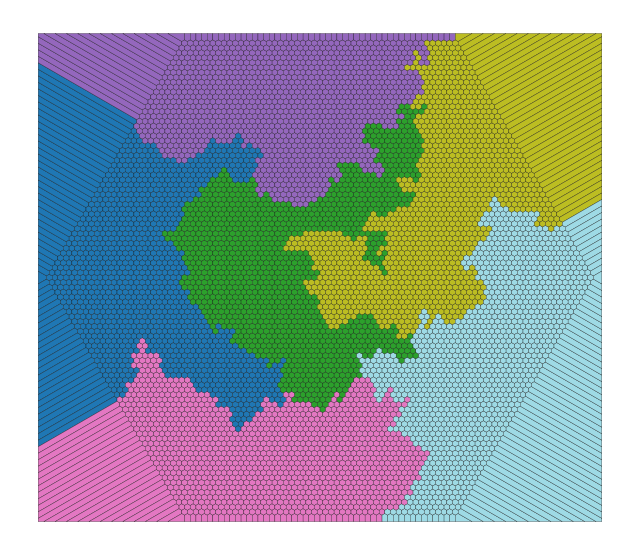

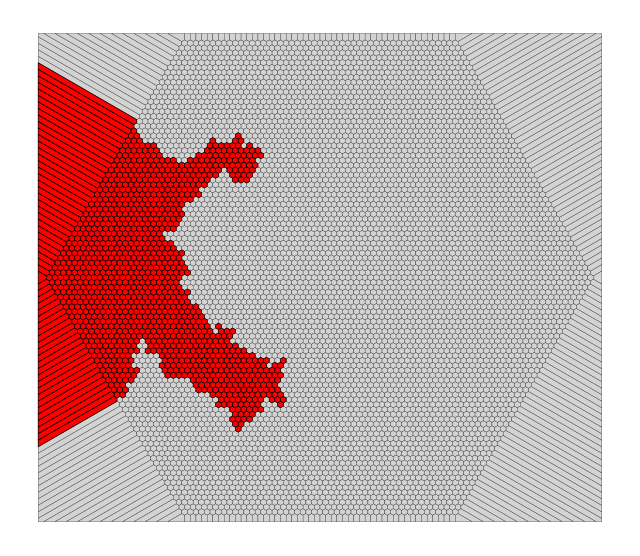

In [6]:
plan = sp.df_plans.iloc[0].plan
labels = sp.decode_plan_vector(plan)
plot_plan(gdf, labels)
plt.show()

district = sp.decode_district(plan[0])
plot_district(gdf, district)
plt.show()

Next, we run hcc and infer clusters at a given number of letters.

In [7]:
sp.load_distance_matrix()
sp.ensure_linkage()

num_letters = num_districts
# num_letters = 12
hc = HClusters(sp)
hc.update_clusters(num_letters)
hc.kcentroids()

  2%|█▊                                                                                           | 1/50 [00:01<00:52,  1.06s/it]

epoch 0: rel_improvement = 0.059421977830290344


  2%|█▊                                                                                           | 1/50 [00:02<01:42,  2.09s/it]


We visualize some letters 

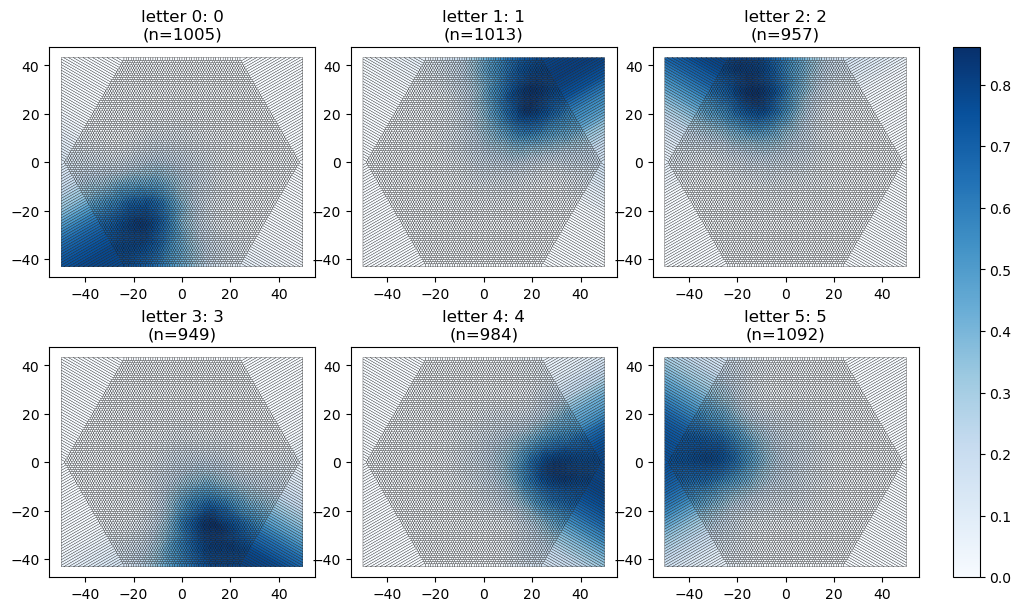

In [8]:
cluster_sizes = np.array([len(hc.c2i[i]) for i in range(num_letters)])

letters = list(range(num_letters))
plot_words_list(gdf, hc.cluster_densities, letters, cluster_sizes=cluster_sizes, cols=3, figsize=(10, 6))
plt.show()

We then use the letters to construct words via beam search with a prescribed `word_degree'

In [9]:
pw = PlanWordBuilder(sp, hc, word_degree=10, verbose=True, centroid_norm="l1").build()
pw.df_words.head()

Enumerating words: 100%|███████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 5236.16it/s]


,plan_uid,plan,word,distance,min_distance,plan_str,word_str,word_uid
0,0,"[0, 1334, 2051, 2829, 5001, 5483]","[0, 1, 2, 4, 4, 5]",5221.0,5221.0,0.1334.2051.2829.5001.5483,0.1.2.4.4.5,39
1,0,"[0, 1334, 2051, 2829, 5001, 5483]","[0, 0, 1, 2, 4, 5]",5260.0,5221.0,0.1334.2051.2829.5001.5483,0.0.1.2.4.5,11
2,0,"[0, 1334, 2051, 2829, 5001, 5483]","[1, 2, 3, 4, 4, 5]",5300.0,5221.0,0.1334.2051.2829.5001.5483,1.2.3.4.4.5,63
3,0,"[0, 1334, 2051, 2829, 5001, 5483]","[0, 1, 2, 3, 4, 5]",5309.0,5221.0,0.1334.2051.2829.5001.5483,0.1.2.3.4.5,37
4,0,"[0, 1334, 2051, 2829, 5001, 5483]","[0, 1, 2, 4, 5, 5]",5380.0,5221.0,0.1334.2051.2829.5001.5483,0.1.2.4.5.5,40


We compute stationary distribution under some POU (controlled by temperature).

In [10]:
ws = WordStat(pw, temp=0.0, verbose=False)
df_top = ws.stationary_table().head(3).reset_index(drop=True)
df_top

,word_uid,word_str,word,stationary
0,37,0.1.2.3.4.5,"[0, 1, 2, 3, 4, 5]",0.101508
1,64,1.2.3.4.5.5,"[1, 2, 3, 4, 5, 5]",0.042698
2,11,0.0.1.2.4.5,"[0, 0, 1, 2, 4, 5]",0.040811


This is the flux matrix

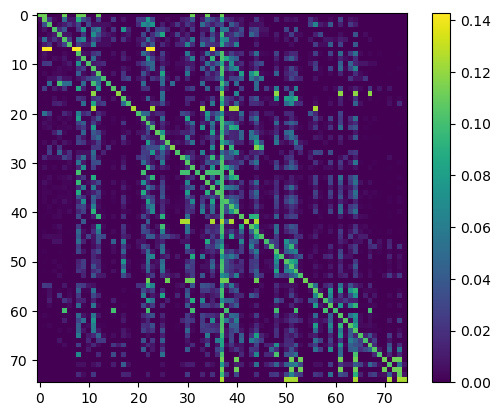

In [11]:
plt.imshow(ws.flux_matrix())
plt.colorbar()

These are some most frequent words under the stationary distribution

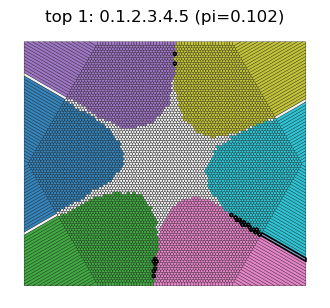

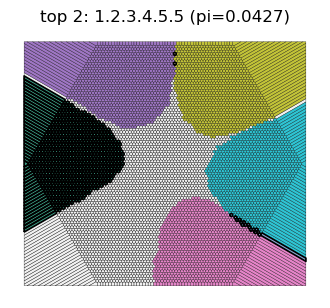

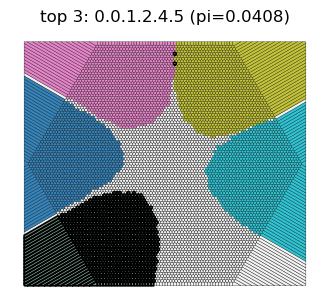

In [12]:
for i, row in df_top.iterrows():
    fig, ax = plot_words_centroids(
        gdf, hc.cluster_densities, row.word, ltr=True, figsize=(4, 4)
    )
    ax.set_title(f"top {i + 1}: {row.word_str} (pi={row.stationary:.3g})")
    plt.show()

Visualize dendrogram from sp linkage

In [13]:
def plot_dendrogram_from_linkage(Z, no_labels=False):
    fig, ax = plt.subplots(figsize=(12, 6))
    dendrogram(Z, ax=ax, no_labels=no_labels)
    ax.set_xlabel("District UID")
    ax.set_ylabel("Merge distance")
    ax.set_title("District clustering dendrogram")
    plt.tight_layout()
    plt.show()
if not is_huge:
    plot_dendrogram_from_linkage(np.load(sp.paths.linkage).astype(np.float64))

In [14]:
# Code by Claude Sonnet 4.6

Z = np.load(sp.paths.linkage).astype(np.float64)
n = int(Z.shape[0] + 1)

from collections import defaultdict

node_to_cluster = {}  # leaf -> cluster id
cluster_members = defaultdict(set)
cluster_first_dist = {}  # cluster id -> distance at which it was first formed
cluster_counter = 0

for i, (a, b, dist, size) in enumerate(Z):
    a, b = int(a), int(b)
    new_node = n + i

    a_leaves = cluster_members[a] if a >= n else {a}
    b_leaves = cluster_members[b] if b >= n else {b}
    cluster_members[new_node] = a_leaves | b_leaves

    a_assigned_leaves = {leaf for leaf in a_leaves if leaf in node_to_cluster}
    b_assigned_leaves = {leaf for leaf in b_leaves if leaf in node_to_cluster}
    a_assigned = len(a_assigned_leaves) > 0
    b_assigned = len(b_assigned_leaves) > 0

    if not a_assigned and not b_assigned:
        cid = cluster_counter
        cluster_counter += 1
        cluster_first_dist[cid] = dist
        for leaf in a_leaves | b_leaves:
            node_to_cluster[leaf] = cid
    elif a_assigned and not b_assigned:
        cid = node_to_cluster[next(iter(a_assigned_leaves))]
        if dist == cluster_first_dist[cid]:
            for leaf in a_leaves | b_leaves:
                node_to_cluster[leaf] = cid
    elif b_assigned and not a_assigned:
        cid = node_to_cluster[next(iter(b_assigned_leaves))]
        if dist == cluster_first_dist[cid]:
            for leaf in a_leaves | b_leaves:
                node_to_cluster[leaf] = cid

# Collect clusters
lowest_level = defaultdict(set)
for leaf, cid in node_to_cluster.items():
    lowest_level[cid].add(leaf)

singletons = [{i} for i in range(n) if i not in node_to_cluster]
all_lowest_clusters = list(lowest_level.values()) + singletons

print(f"{len(all_lowest_clusters)} total lowest-level clusters ({len(singletons)} singletons)")
for c in sorted(all_lowest_clusters, key=len, reverse=True):
    print(sorted(c))

3655 total lowest-level clusters (1310 singletons)
[4854, 4941]
[4981, 5045]
[521, 522]
[1668, 1802]
[707, 767]
[5471, 5472]
[530, 550]
[5208, 5209]
[236, 237]
[5167, 5228]
[1148, 1293]
[1076, 1263]
[4688, 4983]
[4968, 4970]
[4357, 4450]
[4886, 4966]
[607, 608]
[3367, 3368]
[744, 745]
[1444, 1446]
[5355, 5356]
[2333, 2601]
[3282, 3283]
[422, 423]
[1996, 5837]
[211, 214]
[2867, 2869]
[1279, 1366]
[2495, 2496]
[3166, 3360]
[2289, 2290]
[5420, 5453]
[1919, 1920]
[5028, 5029]
[5360, 5419]
[670, 769]
[3482, 3483]
[3500, 3501]
[4294, 4535]
[3193, 3194]
[3557, 4017]
[4112, 4127]
[1669, 1674]
[2635, 2638]
[546, 547]
[763, 764]
[2885, 3063]
[65, 221]
[3533, 3653]
[5211, 5324]
[133, 134]
[996, 997]
[2760, 2953]
[4990, 5256]
[439, 513]
[3449, 3652]
[2284, 2300]
[5015, 5303]
[4509, 5034]
[2822, 3007]
[4099, 4369]
[5948, 5952]
[270, 271]
[1904, 1905]
[3489, 3492]
[4673, 4674]
[5206, 5263]
[298, 299]
[362, 363]
[1084, 1204]
[4470, 4998]
[4745, 4748]
[5223, 5281]
[3377, 3663]
[3726, 4068]
[2995, 3266

In [15]:
if not is_huge:
    all_lowest_clusters = [sorted(c) for c in all_lowest_clusters]
    largest_LL_cluster_size = max([len(c) for c in all_lowest_clusters])
    n_LL_clusters = len(all_lowest_clusters)
    
    fig, axes = plt.subplots(n_LL_clusters, largest_LL_cluster_size)
    
    for i in range(n_LL_clusters):
        for j in range(len(all_lowest_clusters[i])):
            plot_district_by_uid(gdf, sp.df_districts, all_lowest_clusters[i][j], ax=axes[i][j])
            axes[i][j].text(
                -0.05, 0.5, str(all_lowest_clusters[i][j]),
                transform=axes[i][j].transAxes,
                fontsize=7, va="center", ha="right"
            )
        for j in range(len(all_lowest_clusters[i]), largest_LL_cluster_size):
            plot_district(gdf, np.zeros(len(gdf), dtype=bool), ax=axes[i][j])
    plt.tight_layout()
    plt.show()